## Polynomial Regression on Boston Housing Dataset

**In this notebook we do a comparative study of Linear Regression and Polynomial Regression accuracy on the Boston Housing Dataset**

This data was originally a part of UCI Machine Learning Repository and has been removed now. This data also ships with the scikit-learn library. 
There are 506 samples and 13 feature variables in this data-set. The objective is to predict the value of prices of the house using the given features.

The description of all the features is given below:

  **CRIM**: Per capita crime rate by town

  **ZN**: Proportion of residential land zoned for lots over 25,000 sq. ft

  **INDUS**: Proportion of non-retail business acres per town

  **CHAS**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)

  **NOX**: Nitric oxide concentration (parts per 10 million)

  **RM**: Average number of rooms per dwelling

  **AGE**: Proportion of owner-occupied units built prior to 1940

  **DIS**: Weighted distances to five Boston employment centers

  **RAD**: Index of accessibility to radial highways

  **TAX**: Full-value property tax rate per $10,000

  **B**: 1000(Bk - 0.63)², where Bk is the proportion of [people of African American descent] by town

  **LSTAT**: Percentage of lower status of the population

  **MEDV**: Median value of owner-occupied homes in $1000s
  
  
  



I**mport the required Libraries**

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Load the data into pandas dataframe . Load the Boston Housing DataSet from data/boston_house_prices.csv**

In [2]:
Boston = pd.read_csv(r"C:\Users\Eneko\2026-02-BILBAO-FT-Data-Science\3-Machine_Learning\1-Supervisado\1-Regression\2-Polynomial_Regression\ejercicios\data\boston_house_prices.csv")

**Data preprocessing**

Check for missing values in all the columns

In [4]:
Boston.describe()

,506,13,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
count,507,507,507,507,507,507,507,507,507,507,507,507,507,507
unique,505,27,77,3,82,447,357,413,10,67,47,358,456,230
top,0.01501,0,18.1,0,0.538,5.713,100,3.4952,24,666,20.2,396.9,8.05,50
freq,2,372,132,471,23,3,43,5,132,132,140,121,3,16


In [6]:
Boston.info()

<class 'pandas.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   506          507 non-null    str  
 1   13           507 non-null    str  
 2   Unnamed: 2   507 non-null    str  
 3   Unnamed: 3   507 non-null    str  
 4   Unnamed: 4   507 non-null    str  
 5   Unnamed: 5   507 non-null    str  
 6   Unnamed: 6   507 non-null    str  
 7   Unnamed: 7   507 non-null    str  
 8   Unnamed: 8   507 non-null    str  
 9   Unnamed: 9   507 non-null    str  
 10  Unnamed: 10  507 non-null    str  
 11  Unnamed: 11  507 non-null    str  
 12  Unnamed: 12  507 non-null    str  
 13  Unnamed: 13  507 non-null    str  
dtypes: str(14)
memory usage: 55.6 KB


**Data Visualization**

In [7]:
Boston.head()

,506,13,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
1,0.00632,18,2.31,0,0.538,6.575,65.2,4.09,1,296,15.3,396.9,4.98,24
2,0.02731,0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6
3,0.02729,0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
4,0.03237,0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4


In [9]:
# 1. Usar la fila 0 como nombres de columnas
Boston.columns = Boston.iloc[0]

# 2. Eliminar esa fila (y resetear el índice si quieres)
Boston = Boston.drop(Boston.index[0]).reset_index(drop=True)

In [10]:
Boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18,2.31,0,0.538,6.575,65.2,4.09,1,296,15.3,396.9,4.98,24
1,0.02731,0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6
2,0.02729,0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.9,5.33,36.2


**Correlation matrix**

Analyze the correlation matrix. Plot a heatmap

* From correlation plot: which are the columns that are more correlated with **MEDV**
* There are two features highly correlated. Identify them and drop one of them in order to avoid multi-colinearity

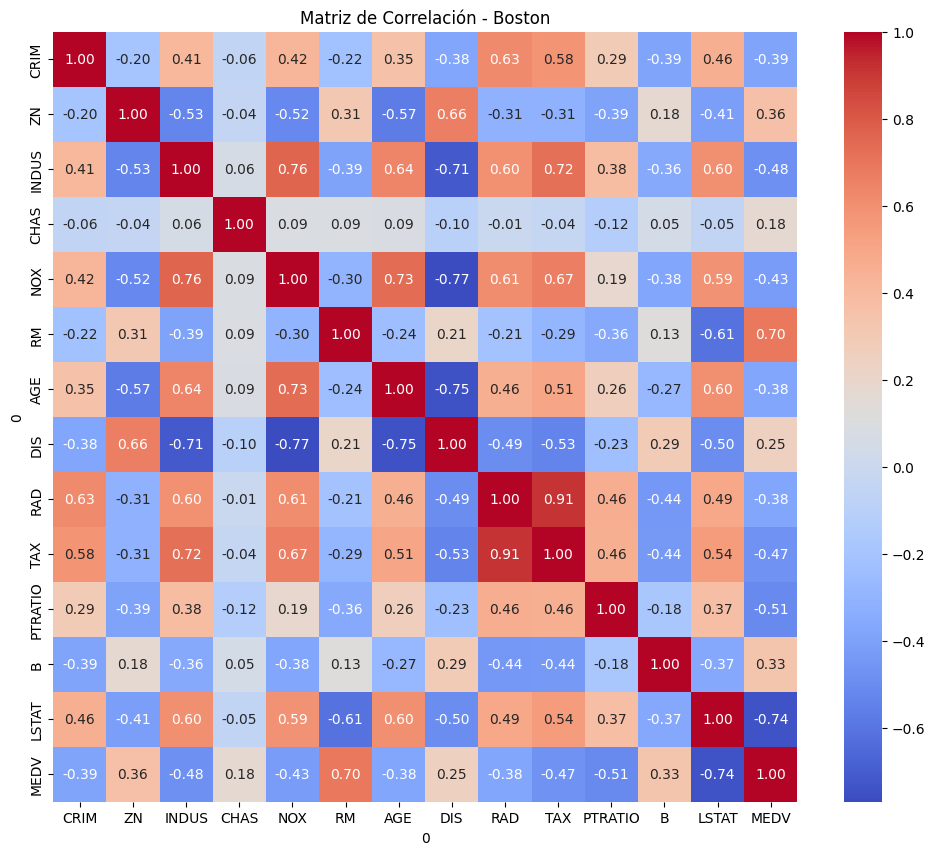

In [ ]:
corr_matrix = Boston.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación - Boston")
plt.show()

# RM(0,70) y LSTAT(-0,74) son las que mayor correlación tienen

### Draw 2 scatter plots to see the relationship between **MEDV** and **LSTAT** and **RM**

In [18]:
# Convertir todas las columnas a números
# 'coerce' transforma cualquier error (si hubiera texto sucio) en NaN
Boston = Boston.apply(pd.to_numeric, errors='coerce')

# Opcional: Si después de convertir tienes valores nulos, puedes borrarlos
Boston = Boston.dropna()

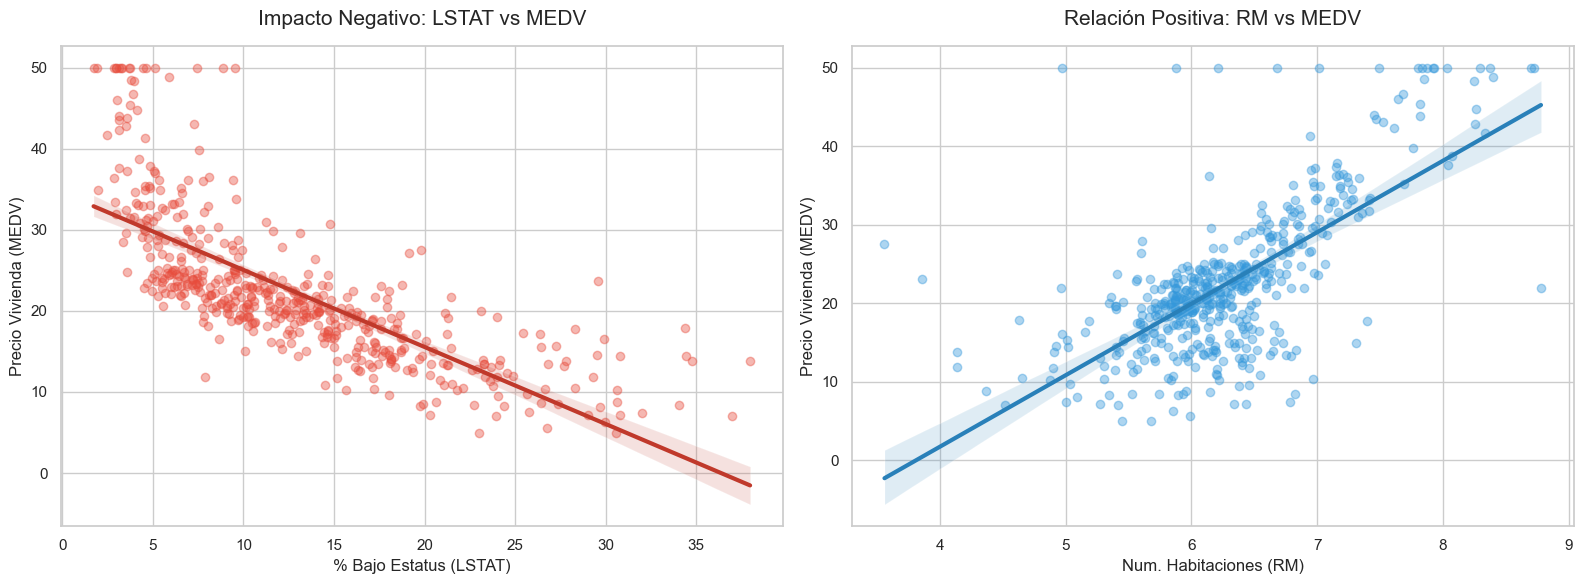

In [19]:
# Configurar un estilo profesional
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. MEDV vs LSTAT con línea de regresión
sns.regplot(ax=axes[0], data=Boston, x='LSTAT', y='MEDV', 
            scatter_kws={'alpha':0.4, 'color':'#e74c3c'}, 
            line_kws={'color':'#c0392b', 'lw':3})
axes[0].set_title('Impacto Negativo: LSTAT vs MEDV', fontsize=15, pad=15)
axes[0].set_xlabel('% Bajo Estatus (LSTAT)', fontsize=12)
axes[0].set_ylabel('Precio Vivienda (MEDV)', fontsize=12)

# 2. MEDV vs RM con línea de regresión
sns.regplot(ax=axes[1], data=Boston, x='RM', y='MEDV', 
            scatter_kws={'alpha':0.4, 'color':'#3498db'}, 
            line_kws={'color':'#2980b9', 'lw':3})
axes[1].set_title('Relación Positiva: RM vs MEDV', fontsize=15, pad=15)
axes[1].set_xlabel('Num. Habitaciones (RM)', fontsize=12)
axes[1].set_ylabel('Precio Vivienda (MEDV)', fontsize=12)

plt.tight_layout()
plt.show()

**Prepare the data for training**
Create a dataframe X including **LSTAT** and **RM** columns.
Y should be a pandas series including target values **'MEDV'**


In [20]:
# Crear el DataFrame de características (X)
X = Boston[['LSTAT', 'RM']]

# Crear la serie objetivo (y)
y = Boston['MEDV']

**Split the data into training and testing sets**

Splits the training and test data set in 80% : 20%. Assign random_state to any value. This ensures consistency. Print the sahes of the resulting objects

In [21]:
from sklearn.model_selection import train_test_split

In [23]:
# Dividir los datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

# Imprimir los shapes de los objetos resultantes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (404, 2)
X_test shape:  (102, 2)
y_train shape: (404,)
y_test shape:  (102,)


# **Linear Regression**

Build a linear regression model with sklearn LinearRegression.
We'll use Mean Squared error and R2 score to evaluate our model, so be sure to make the needed imports.

Import the necessary functions and train a LinearRegression model

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**Evaluate the model performance in the training and testing sets**

In [26]:
lin_model = LinearRegression()

#Entrenar el modelo con los datos de entrenamiento
lin_model.fit(X_train, y_train)

# Realizar predicciones sobre el set de entrenamiento para evaluación interna
y_train_predict = lin_model.predict(X_train)

# Calcular métricas para el set de entrenamiento
rmse = (np.sqrt(mean_squared_error(y_train, y_train_predict)))
r2 = r2_score(y_train, y_train_predict)

print("El rendimiento del modelo para el set de entrenamiento:")
print("------------------------------------------------------")
print(f"RMSE es {rmse}")
print(f"R2 score es {r2}")

El rendimiento del modelo para el set de entrenamiento:
------------------------------------------------------
RMSE es 5.703303651626608
R2 score es 0.6240303846249815


**Lets see the model performance visually. Let's plot y_test vs y_pred**

Plotting the y_test vs y_pred. Ideally should have been a straight line

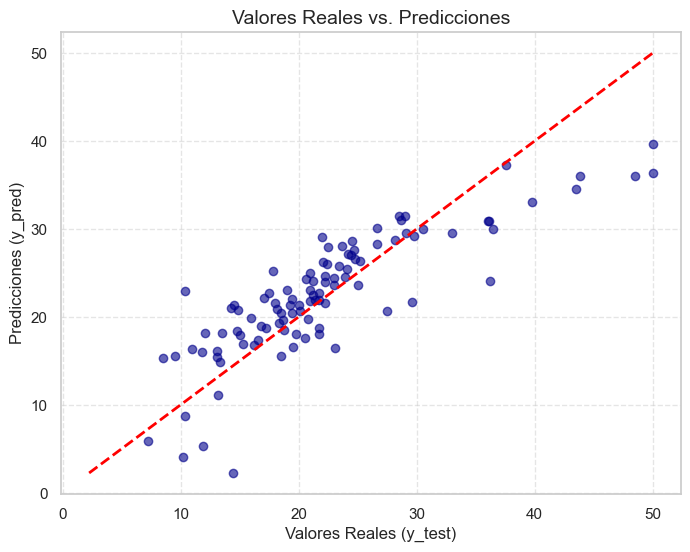

In [28]:
# 1. Realizar las predicciones sobre el set de prueba
y_pred = lin_model.predict(X_test)

# 2. Graficar
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='darkblue')

# Dibujar la línea de "Predicción Perfecta"
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--')

plt.title('Valores Reales vs. Predicciones', fontsize=14)
plt.xlabel('Valores Reales (y_test)', fontsize=12)
plt.ylabel('Predicciones (y_pred)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# **Polynomial Regression**

We can see that **LSTAT** doesn't vary exactly in a linear way. Let's apply the Polynomial Regression with **degree 2** and test. 

To generate the higher order degrees, we use PolyniomialFeatures class from sklearn library. 

In [29]:
from sklearn.preprocessing import PolynomialFeatures

# Crear el transformador polinomial de grado 2
poly_features = PolynomialFeatures(degree=2)

# Transformar las características de entrenamiento y prueba
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

# Entrenar el modelo de Regresión Lineal con las nuevas características
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Realizar predicciones
y_train_poly_pred = poly_model.predict(X_train_poly)
y_test_poly_pred = poly_model.predict(X_test_poly)

# Evaluar el rendimiento en el set de prueba
rmse_poly = np.sqrt(mean_squared_error(y_test, y_test_poly_pred))
r2_poly = r2_score(y_test, y_test_poly_pred)

print("Rendimiento Polinomial")
print(f"RMSE: {rmse_poly:.2f}")
print(f"R2 Score: {r2_poly:.2f}")

Rendimiento Polinomial
RMSE: 3.86
R2 Score: 0.80


**Did the model improve using the Polynomial model?**

In [ ]:
# Ha mejorado de 0.62 a 0.80

**Did the model improve using the Polynomial model with degree 3? Or more?**

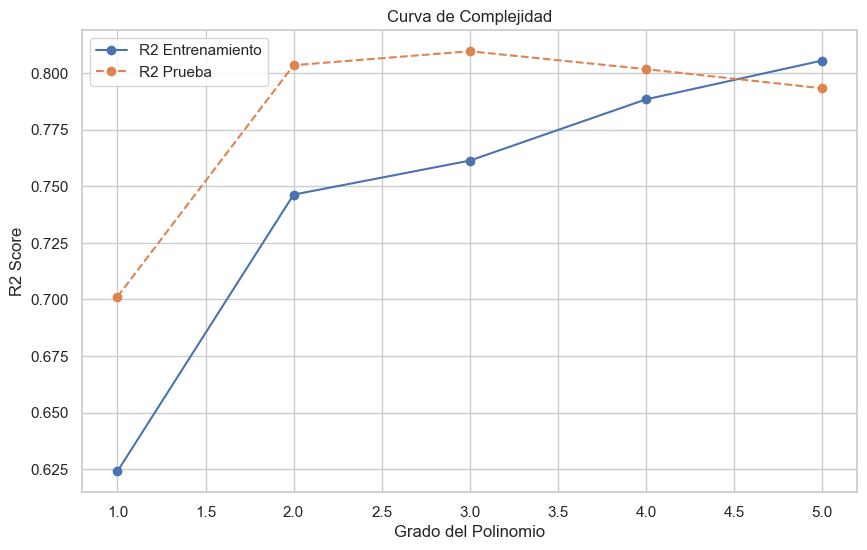

In [31]:
degrees = [1, 2, 3, 4, 5]
r2_train_list = []
r2_test_list = []

for d in degrees:
    # 1. Transformar a grado 'd'
    poly = PolynomialFeatures(degree=d)
    X_train_p = poly.fit_transform(X_train)
    X_test_p = poly.transform(X_test)
    
    # 2. Entrenar modelo
    model = LinearRegression()
    model.fit(X_train_p, y_train)
    
    # 3. Guardar R2 scores
    r2_train_list.append(r2_score(y_train, model.predict(X_train_p)))
    r2_test_list.append(r2_score(y_test, model.predict(X_test_p)))

# Visualizar la tendencia
plt.figure(figsize=(10, 6))
plt.plot(degrees, r2_train_list, label='R2 Entrenamiento', marker='o')
plt.plot(degrees, r2_test_list, label='R2 Prueba', marker='o', linestyle='--')
plt.xlabel('Grado del Polinomio')
plt.ylabel('R2 Score')
plt.title('Curva de Complejidad')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# Encontrar el índice del valor máximo en la lista de R2 de prueba
best_idx = np.argmax(r2_test_list)
best_degree = degrees[best_idx]
best_r2 = r2_test_list[best_idx]

print(f"El punto dulce es el Grado: {best_degree}")
print(f"Con un R2 de Prueba de: {best_r2:.4f}")

El punto dulce es el Grado: 3
Con un R2 de Prueba de: 0.8098


In [33]:
# Crear el transformador polinomial de grado 2
poly_features = PolynomialFeatures(degree=3)

# Transformar las características de entrenamiento y prueba
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

# Entrenar el modelo de Regresión Lineal con las nuevas características
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Realizar predicciones
y_train_poly_pred = poly_model.predict(X_train_poly)
y_test_poly_pred = poly_model.predict(X_test_poly)

# Evaluar el rendimiento en el set de prueba
rmse_poly = np.sqrt(mean_squared_error(y_test, y_test_poly_pred))
r2_poly = r2_score(y_test, y_test_poly_pred)

print("Rendimiento Polinomial")
print(f"RMSE: {rmse_poly:.2f}")
print(f"R2 Score: {r2_poly:.2f}")

Rendimiento Polinomial
RMSE: 3.80
R2 Score: 0.81
